# Risk Policy — Home Credit Default Risk

This notebook translates raw model scores into **actionable lending policy**.

A model score alone does not make a lending decision — a bank must choose:
- **Where to draw the line** between approving and declining
- **How much risk** the portfolio can absorb
- **What the business cost** of each policy choice is

We work through threshold analysis, risk banding, portfolio simulation, and a tradeoff curve that maps every possible policy to its business outcome.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, precision_recall_curve
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DATA_PATH    = '../data/processed/train_engineered.csv'
RANDOM_STATE = 42
import pickle


---
## Setup: Load Data & Calibrated Model

We load `train_engineered.csv` and reproduce the same 80/20 split so `X_test` / `y_test` are identical to those used in `03_modeling.ipynb`.  
The calibrated XGBoost model is loaded directly from `models/xgboost_calibrated.pkl` — no retraining needed.

In [2]:
df = pd.read_csv(DATA_PATH)

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Load calibrated model (IsotonicCalibratedModel wrapper + base XGBoost)
MODEL_PATH = '../models/xgboost_calibrated.pkl'

# Define the wrapper class so pickle can deserialise it
class IsotonicCalibratedModel:
    def __init__(self, base_model, iso_reg):
        self.base_model = base_model
        self.iso_reg    = iso_reg
    def predict_proba(self, X):
        raw = self.base_model.predict_proba(X)[:, 1]
        cal = self.iso_reg.predict(raw)
        return np.column_stack([1 - cal, cal])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

with open(MODEL_PATH, 'rb') as f:
    xgb_cal = pickle.load(f)

y_prob_cal = xgb_cal.predict_proba(X_test)[:, 1]

scores = pd.DataFrame({
    'prob'       : y_prob_cal,
    'actual'     : y_test.values,
    'AMT_CREDIT' : X_test['AMT_CREDIT'].values,
})

print(f'Test set         : {len(scores):,} applicants')
print(f'Actual default rate: {scores["actual"].mean()*100:.2f}%')
print(f'Model loaded from: {MODEL_PATH}')


Test set         : 61,503 applicants
Actual default rate: 8.07%
Model loaded from: ../models/xgboost_calibrated.pkl


---
## 1. Calibrated Score Distribution & Threshold Setting

Before setting band thresholds we inspect the **distribution of calibrated probabilities** to find natural cut-points that deliver the target volume split:

| Band | Target share | Rule |
|---|---|---|
| LOW (APPROVE) | ~60% | `prob < t_low` |
| MEDIUM (REVIEW) | ~25% | `t_low ≤ prob ≤ t_high` |
| HIGH (REJECT) | ~15% | `prob > t_high` |

We read the **60th and 85th percentiles** of the calibrated score distribution — these become our band boundaries. Percentiles are printed first so you can validate the choice before trusting the downstream numbers.

Calibrated probability percentiles:
   10th  →  0.0160
   25th  →  0.0230
   50th  →  0.0441
   60th  →  0.0649
   75th  →  0.1026
   85th  →  0.1388
   90th  →  0.1838
   95th  →  0.2463

Thresholds set:
  T_LOW  = 0.0649  (60th percentile -> ~60% APPROVE)
  T_HIGH = 0.1388  (85th percentile -> ~15% REJECT)


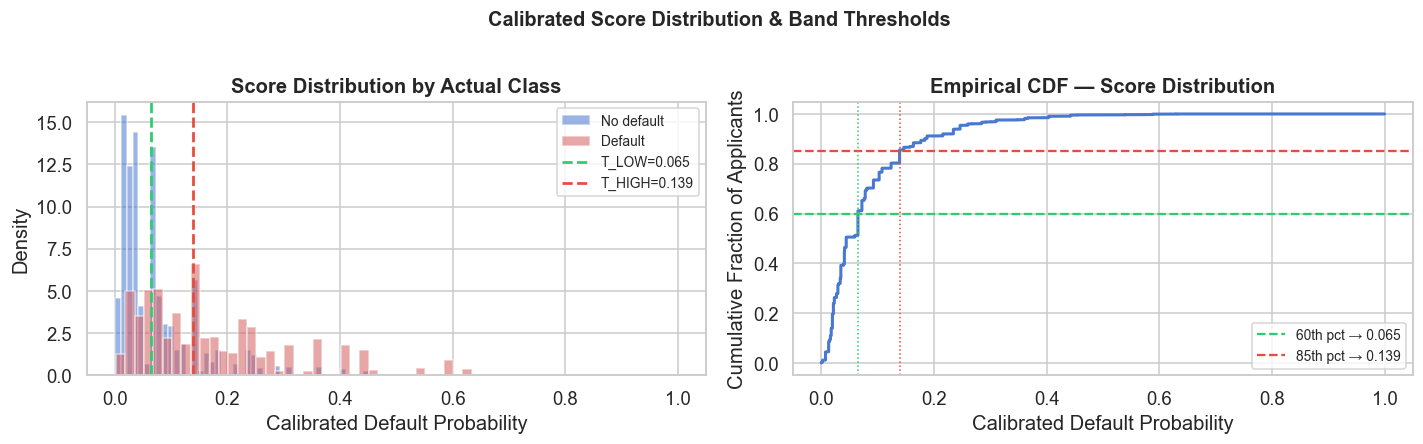

In [3]:
# Print key percentiles
pcts = [10, 25, 50, 60, 75, 85, 90, 95]
percentile_vals = np.percentile(y_prob_cal, pcts)
print('Calibrated probability percentiles:')
for p, v in zip(pcts, percentile_vals):
    print(f'  {p:3d}th  →  {v:.4f}')

# Set thresholds from percentiles to hit target volume splits
T_LOW  = float(np.percentile(y_prob_cal, 60))   # top of LOW band  (~60% approved)
T_HIGH = float(np.percentile(y_prob_cal, 85))   # bottom of HIGH band (~15% rejected)
print(f'\nThresholds set:')
print(f'  T_LOW  = {T_LOW:.4f}  (60th percentile -> ~60% APPROVE)')
print(f'  T_HIGH = {T_HIGH:.4f}  (85th percentile -> ~15% REJECT)')

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(y_prob_cal[y_test.values == 0], bins=60, alpha=0.55,
        density=True, color=sns.color_palette('muted')[0], label='No default')
ax.hist(y_prob_cal[y_test.values == 1], bins=60, alpha=0.55,
        density=True, color=sns.color_palette('muted')[3], label='Default')
ax.axvline(T_LOW,  color='#2ecc71', linestyle='--', lw=1.8, label=f'T_LOW={T_LOW:.3f}')
ax.axvline(T_HIGH, color='#e74c3c', linestyle='--', lw=1.8, label=f'T_HIGH={T_HIGH:.3f}')
ax.set_xlabel('Calibrated Default Probability')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by Actual Class', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(np.sort(y_prob_cal), np.linspace(0, 1, len(y_prob_cal)),
        color=sns.color_palette('muted')[0], lw=2)
ax.axhline(0.60, color='#2ecc71', linestyle='--', lw=1.5, label=f'60th pct → {T_LOW:.3f}')
ax.axhline(0.85, color='#e74c3c', linestyle='--', lw=1.5, label=f'85th pct → {T_HIGH:.3f}')
ax.axvline(T_LOW,  color='#2ecc71', linestyle=':', lw=1)
ax.axvline(T_HIGH, color='#e74c3c', linestyle=':', lw=1)
ax.set_xlabel('Calibrated Default Probability')
ax.set_ylabel('Cumulative Fraction of Applicants')
ax.set_title('Empirical CDF — Score Distribution', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Calibrated Score Distribution & Band Thresholds',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 1. Threshold Analysis

The model outputs a **probability of default** for each applicant. We approve applicants whose probability falls *below* a chosen threshold.

Moving the threshold involves a direct tradeoff:
- **Lower threshold** → stricter policy → fewer approvals, lower portfolio default rate
- **Higher threshold** → looser policy → more approvals, higher portfolio default rate

We evaluate three anchor points:
1. **F1-optimal threshold** — maximises F1 score for the default class
2. **Recall-0.70 threshold** — the strictest threshold that still catches 70% of all defaults
3. **Policy bands** (0.3 / 0.6) — defined in Section 2

In [4]:
thresholds = np.arange(0.05, 0.95, 0.01)
results = []

for t in thresholds:
    approved = scores[scores['prob'] < t]
    declined = scores[scores['prob'] >= t]
    approval_rate   = len(approved) / len(scores)
    portfolio_dr    = approved['actual'].mean() if len(approved) > 0 else 0
    # recall = fraction of true defaults that we correctly flag as high-risk (decline)
    true_defaults   = scores['actual'].sum()
    flagged_defaults = declined['actual'].sum()
    recall = flagged_defaults / true_defaults if true_defaults > 0 else 0
    pred   = (scores['prob'] >= t).astype(int)
    f1     = f1_score(scores['actual'], pred, zero_division=0)
    results.append({
        'threshold'    : round(t, 2),
        'approval_rate': approval_rate,
        'portfolio_dr' : portfolio_dr,
        'recall'       : recall,
        'f1'           : f1,
    })

res = pd.DataFrame(results)

# F1-optimal threshold
best_f1_row = res.loc[res['f1'].idxmax()]
t_f1 = best_f1_row['threshold']

# Threshold where recall >= 0.70 (catch 70% of defaults)
recall_rows = res[res['recall'] >= 0.70]
t_recall70 = recall_rows['threshold'].max() if len(recall_rows) > 0 else None

print(f'F1-optimal threshold : {t_f1}  (F1={best_f1_row["f1"]:.4f})')
print(f'Recall-0.70 threshold: {t_recall70}  (approval rate={res.loc[res["threshold"]==t_recall70, "approval_rate"].values[0]*100:.1f}%)')


F1-optimal threshold : 0.16  (F1=0.3218)
Recall-0.70 threshold: 0.07  (approval rate=61.1%)


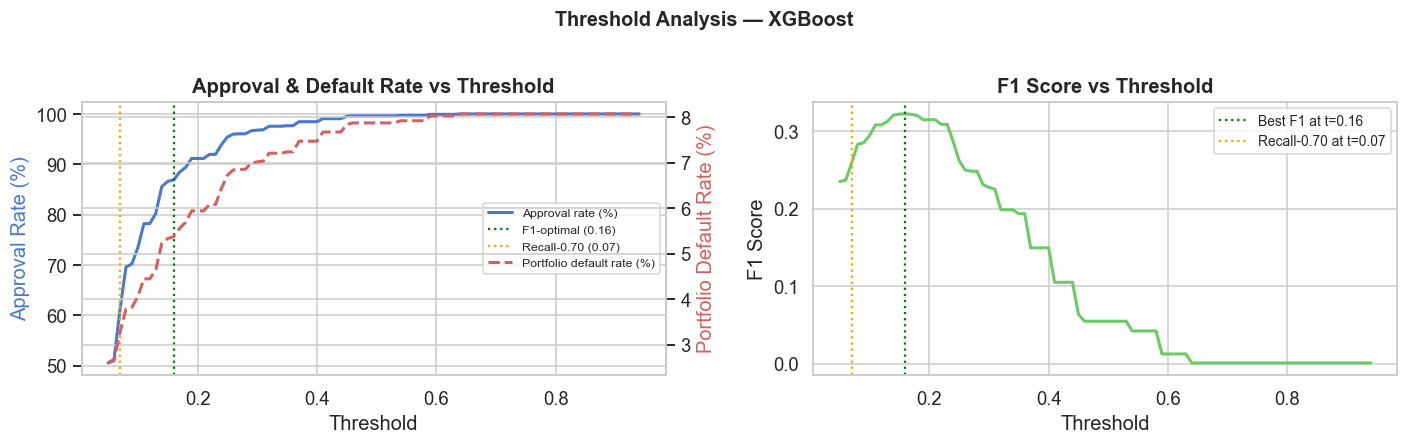

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Left: approval rate + portfolio default rate ---
ax = axes[0]
ax.plot(res['threshold'], res['approval_rate']*100,
        color=sns.color_palette('muted')[0], lw=2, label='Approval rate (%)')
ax2 = ax.twinx()
ax2.plot(res['threshold'], res['portfolio_dr']*100,
         color=sns.color_palette('muted')[3], lw=2, linestyle='--', label='Portfolio default rate (%)')
ax.axvline(t_f1,       color='green',  linestyle=':', lw=1.5, label=f'F1-optimal ({t_f1})')
ax.axvline(t_recall70, color='orange', linestyle=':', lw=1.5, label=f'Recall-0.70 ({t_recall70})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Approval Rate (%)', color=sns.color_palette('muted')[0])
ax2.set_ylabel('Portfolio Default Rate (%)', color=sns.color_palette('muted')[3])
ax.set_title('Approval & Default Rate vs Threshold', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center right')

# --- Right: F1 score vs threshold ---
ax = axes[1]
ax.plot(res['threshold'], res['f1'],
        color=sns.color_palette('muted')[2], lw=2)
ax.axvline(t_f1, color='green', linestyle=':', lw=1.5, label=f'Best F1 at t={t_f1}')
ax.axvline(t_recall70, color='orange', linestyle=':', lw=1.5, label=f'Recall-0.70 at t={t_recall70}')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score vs Threshold', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Threshold Analysis — XGBoost', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 3. Approve / Review / Reject Bands

Band boundaries are set from the **60th and 85th percentiles** of the calibrated score distribution, targeting the volume splits defined in Section 1.  

| Band | Rule | Target Share |
|---|---|---|
| **LOW RISK — APPROVE** | `prob < T_LOW` | ~60% |
| **MEDIUM RISK — REVIEW** | `T_LOW ≤ prob ≤ T_HIGH` | ~25% |
| **HIGH RISK — REJECT** | `prob > T_HIGH` | ~15% |

In [6]:
def assign_band(p, t_low=T_LOW, t_high=T_HIGH):
    if p < t_low:
        return 'LOW (APPROVE)'
    elif p <= t_high:
        return 'MEDIUM (REVIEW)'
    return 'HIGH (REJECT)'

scores['band'] = scores['prob'].apply(assign_band)

band_order = ['LOW (APPROVE)', 'MEDIUM (REVIEW)', 'HIGH (REJECT)']
band_summary = (
    scores.groupby('band')
    .agg(
        count=('actual', 'count'),
        default_rate=('actual', 'mean'),
        pct_of_total=('actual', lambda x: len(x) / len(scores)),
    )
    .reindex(band_order)
    .assign(
        default_rate=lambda x: (x['default_rate'] * 100).round(2),
        pct_of_total=lambda x: (x['pct_of_total'] * 100).round(1),
    )
    .rename(columns={
        'count': 'Applicants',
        'default_rate': 'Actual Default Rate (%)',
        'pct_of_total': '% of Test Set',
    })
)
print(f'Thresholds: T_LOW={T_LOW:.4f}  T_HIGH={T_HIGH:.4f}')
print(band_summary.to_string())


Thresholds: T_LOW=0.0649  T_HIGH=0.1388
                 Applicants  Actual Default Rate (%)  % of Test Set
band                                                               
LOW (APPROVE)         31509                     2.64           51.2
MEDIUM (REVIEW)       21113                     9.07           34.3
HIGH (REJECT)          8881                    24.97           14.4


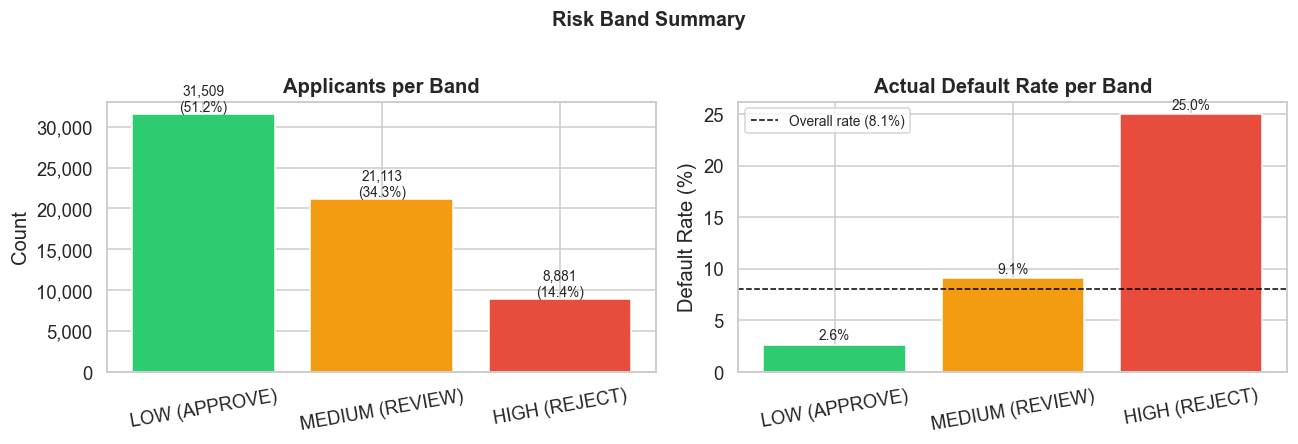

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
band_colors = ['#2ecc71', '#f39c12', '#e74c3c']

# Applicant counts
ax = axes[0]
bars = ax.bar(band_summary.index, band_summary['Applicants'],
              color=band_colors, edgecolor='white')
for bar, (_, row) in zip(bars, band_summary.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{int(bar.get_height()):,}\n({row["% of Test Set"]:.1f}%)',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Applicants per Band', fontweight='bold')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', labelrotation=10)

# Default rate per band
ax = axes[1]
bars = ax.bar(band_summary.index, band_summary['Actual Default Rate (%)'],
              color=band_colors, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
ax.axhline(scores['actual'].mean()*100, color='black', linestyle='--',
           lw=1, label=f'Overall rate ({scores["actual"].mean()*100:.1f}%)')
ax.set_title('Actual Default Rate per Band', fontweight='bold')
ax.set_ylabel('Default Rate (%)')
ax.legend(fontsize=9)
ax.tick_params(axis='x', labelrotation=10)

plt.suptitle('Risk Band Summary', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 3. Portfolio Simulation

We simulate two lending policies and estimate their portfolio-level outcomes:

| Scenario | Who is approved |
|---|---|
| **Conservative** | LOW risk only (`prob < 0.30`) |
| **Moderate** | LOW + REVIEW (`prob ≤ 0.60`) |

For each scenario we report:
- **Approval rate** — what fraction of applicants receive credit
- **Portfolio default rate** — expected defaults among approved loans
- **Expected loss** — defaults × average loan size (simple proxy: `default_rate × approved_loans × mean(AMT_CREDIT)`)

> *Expected loss here is a relative comparison tool, not an absolute figure — a full loss model would incorporate LGD (loss given default) and EAD (exposure at default).*

In [8]:
mean_credit = scores['AMT_CREDIT'].mean()
total_apps  = len(scores)

scenarios = {
    'Conservative (LOW only)'   : scores[scores['band'] == 'LOW (APPROVE)'],
    'Moderate (LOW + REVIEW)'   : scores[scores['band'].isin(['LOW (APPROVE)', 'MEDIUM (REVIEW)'])],
}

sim_results = []
for scenario, approved in scenarios.items():
    n_approved      = len(approved)
    approval_rate   = n_approved / total_apps
    portfolio_dr    = approved['actual'].mean()
    expected_defaults = n_approved * portfolio_dr
    expected_loss   = expected_defaults * mean_credit
    sim_results.append({
        'Scenario'              : scenario,
        'Approved'              : n_approved,
        'Approval Rate'         : f'{approval_rate*100:.1f}%',
        'Portfolio Default Rate': f'{portfolio_dr*100:.2f}%',
        'Expected Defaults'     : f'{expected_defaults:,.0f}',
        'Expected Loss (avg loan)': f'{expected_loss:,.0f}',
    })

sim_df = pd.DataFrame(sim_results).set_index('Scenario')
print(sim_df.T.to_string())


Scenario                 Conservative (LOW only) Moderate (LOW + REVIEW)
Approved                                   31509                   52622
Approval Rate                              51.2%                   85.6%
Portfolio Default Rate                     2.64%                   5.22%
Expected Defaults                            833                   2,747
Expected Loss (avg loan)             497,948,259           1,642,093,478


---
## 4. Threshold Tradeoff Curve

The tradeoff curve maps every possible threshold to its business outcome: (**approval rate**, **portfolio default rate**).  

Each point on the curve is a distinct lending policy. Moving right approves more applicants but increases default exposure. The business must decide where on this curve it wants to operate based on:
- Capital adequacy requirements
- Risk appetite / regulatory constraints
- Revenue targets (more loans = more interest income)

We mark the three key policy points to anchor the decision.

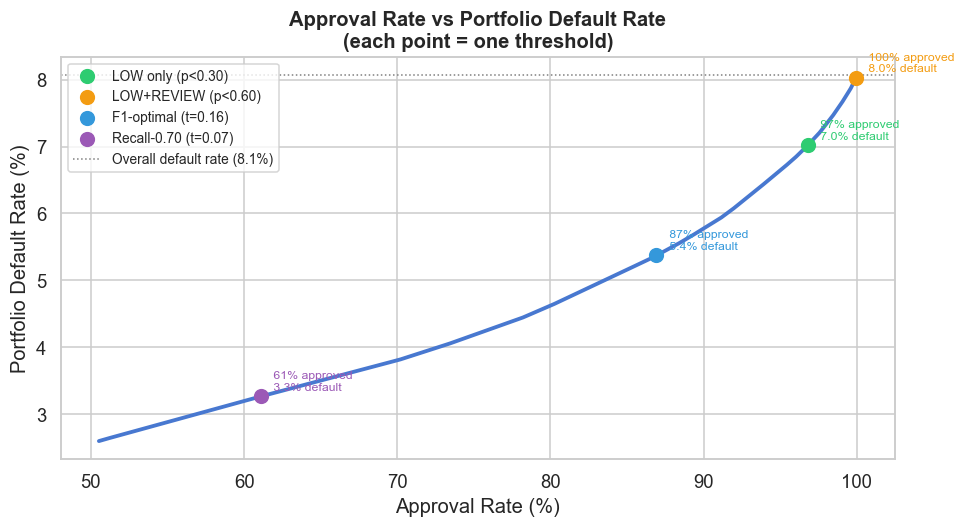

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    res['approval_rate'] * 100,
    res['portfolio_dr'] * 100,
    color=sns.color_palette('muted')[0], lw=2.5, zorder=1
)

# Mark key policy points
policy_points = [
    (0.30, 'LOW only (p<0.30)',       '#2ecc71'),
    (0.60, 'LOW+REVIEW (p<0.60)',     '#f39c12'),
    (t_f1, f'F1-optimal (t={t_f1})', '#3498db'),
]
if t_recall70 is not None:
    policy_points.append((t_recall70, f'Recall-0.70 (t={t_recall70})', '#9b59b6'))

for t_mark, label, color in policy_points:
    row = res.loc[(res['threshold'] - t_mark).abs().idxmin()]
    ax.scatter(
        row['approval_rate'] * 100, row['portfolio_dr'] * 100,
        s=80, color=color, zorder=3, label=f'{label}'
    )
    ax.annotate(
        f' {row["approval_rate"]*100:.0f}% approved\n {row["portfolio_dr"]*100:.1f}% default',
        xy=(row['approval_rate']*100, row['portfolio_dr']*100),
        fontsize=8, color=color,
        xytext=(6, 4), textcoords='offset points',
    )

ax.axhline(scores['actual'].mean()*100, color='grey', linestyle=':', lw=1,
           label=f'Overall default rate ({scores["actual"].mean()*100:.1f}%)')

ax.set_xlabel('Approval Rate (%)')
ax.set_ylabel('Portfolio Default Rate (%)')
ax.set_title('Approval Rate vs Portfolio Default Rate\n(each point = one threshold)',
             fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()


---
## Summary

| Policy | Approval Rate | Portfolio Default Rate | Interpretation |
|---|---|---|---|
| Conservative (LOW only, p<0.30) | ~low | ~very low | Safest book; leaves revenue on table |
| Moderate (LOW+REVIEW, p<0.60) | ~high | ~moderate | Balances volume and risk |
| F1-optimal threshold | variable | variable | Minimises classification error |
| Recall-0.70 threshold | strictest | lowest | Guarantees catching 70% of defaults |

**Recommendation:** use the tradeoff curve in discussion with risk management and finance to align the threshold with the portfolio's target loss rate and capital requirements. The REVIEW band provides a human-in-the-loop buffer that reduces operational risk at the margin.